# Shovel 2D Cartesian Control Scratchpad
Control a single shovel link as a 2D Cartesian robot with two prismatic joints (X, Y) and one revolute joint (orientation)

## Section 1: Import Required Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy.random import seed
import pybullet as p
import pybullet_data
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2
from IPython.display import clear_output
import time as t

# seed random number generator
seed(42)

%matplotlib inline

pybullet build time: Sep  3 2024 12:52:02


## Section 2: Load and Visualize the Shovel URDF Model

In [2]:
# Initialize PyBullet environment
physicsClient = p.connect(p.GUI)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

# Load ground plane
planeId = p.loadURDF("plane.urdf")

# Load the shovel robot
startPos = [0, 0, 0.026]
startOrientation = p.getQuaternionFromEuler([0, 0, 0])
shovel_urdf = './urdf/shovel/shovelFlat.urdf'

robotId = p.loadURDF(shovel_urdf, startPos, startOrientation)
print(f"Shovel loaded: robotId = {robotId}")

startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Intel
GL_RENDERER=Mesa Intel(R) Iris(R) Xe Graphics (RPL-P)
GL_VERSION=4.6 (Core Profile) Mesa 25.2.8-0ubuntu0.24.04.1
GL_SHADING_LANGUAGE_VERSION=4.60
pthread_getconcurrency()=0
Version = 4.6 (Core Profile) Mesa 25.2.8-0ubuntu0.24.04.1
Vendor = Intel
Renderer = Mesa Intel(R) Iris(R) Xe Graphics (RPL-P)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubunt

In [3]:
# Optional: scatter pebbles in front of the shovel (similar to rover scratchpad)
minpos = np.array([0.2, -1.5, 0.0])
maxpos = np.array([3.0,  1.5, 0.0])
num_pebbles = 50
pebble_urdf = './urdf/pebbles/pebbles.urdf'

aggregate_ids = []
for _ in range(num_pebbles):
    start_pos = minpos + (np.random.rand(3) * (maxpos - minpos))
    start_pos[-1] = 0.2
    start_quat = p.getQuaternionFromEuler([0, 0, 0])
    pebble_id = p.loadURDF(pebble_urdf, start_pos, start_quat)
    aggregate_ids.append(pebble_id)

for _ in range(120):
    p.stepSimulation()

print(f"Scattered {len(aggregate_ids)} pebbles in workspace area.")
# Alternative clustered distribution (manual implementation) can be added if needed.

Scattered 50 pebbles in workspace area.


## Section 3: Set Up the Kinematic Chain

In [4]:
# Get joint information
num_joints = p.getNumJoints(robotId)
print(f"\nTotal joints: {num_joints}")
print("\nJoint Information:")
print("-" * 80)

joint_info = {}
prismatic_joints = []  # X and Y movement
revolute_joints = []   # Rotation joints
fixed_joints = []

for i in range(num_joints):
    info = p.getJointInfo(robotId, i)
    joint_name = info[1].decode('utf-8')
    joint_type = info[2]  # 0=REVOLUTE, 1=PRISMATIC, 2=SPHERICAL, 3=PLANAR, 4=FIXED
    joint_type_str = {0: 'REVOLUTE', 1: 'PRISMATIC', 2: 'SPHERICAL', 3: 'PLANAR', 4: 'FIXED'}.get(joint_type, 'UNKNOWN')
    
    print(f"Joint {i}: {joint_name:20s} - Type: {joint_type_str:10s}")
    
    joint_info[joint_name] = {
        'index': i,
        'type': joint_type,
        'type_str': joint_type_str,
        'info': info
    }
    
    if joint_type == 1:  # PRISMATIC
        prismatic_joints.append(i)
    elif joint_type == 0:  # REVOLUTE
        revolute_joints.append(i)
    elif joint_type == 4:  # FIXED
        fixed_joints.append(i)

print(f"\nPrismatic joints (indices): {prismatic_joints}")
print(f"Revolute joints (indices): {revolute_joints}")
print(f"Fixed joints (indices): {fixed_joints}")

# Define the control joints for 2D Cartesian control
# X motion (first prismatic), Y motion (second prismatic), Orientation (revolute)
joint_x_idx = prismatic_joints[0] if len(prismatic_joints) > 0 else None
joint_y_idx = prismatic_joints[1] if len(prismatic_joints) > 1 else None
joint_theta_idx = revolute_joints[-1] if len(revolute_joints) > 0 else None  # Use last revolute for orientation

print(f"\n2D Cartesian Control Configuration:")
print(f"  X motion joint: {joint_x_idx} - {joint_info[list(joint_info.keys())[joint_x_idx]]['info'][1].decode() if joint_x_idx is not None else 'N/A'}")
print(f"  Y motion joint: {joint_y_idx} - {joint_info[list(joint_info.keys())[joint_y_idx]]['info'][1].decode() if joint_y_idx is not None else 'N/A'}")
print(f"  Theta joint: {joint_theta_idx} - {joint_info[list(joint_info.keys())[joint_theta_idx]]['info'][1].decode() if joint_theta_idx is not None else 'N/A'}")


Total joints: 3

Joint Information:
--------------------------------------------------------------------------------
Joint 0: base_L1_joint        - Type: PRISMATIC 
Joint 1: L1_L2_joint          - Type: PRISMATIC 
Joint 2: L2_EE_joint          - Type: REVOLUTE  

Prismatic joints (indices): [0, 1]
Revolute joints (indices): [2]
Fixed joints (indices): []

2D Cartesian Control Configuration:
  X motion joint: 0 - base_L1_joint
  Y motion joint: 1 - L1_L2_joint
  Theta joint: 2 - L2_EE_joint


## Section 4: Define 2D Cartesian Control Parameters

In [5]:
# Get joint limits for prismatic and revolute joints
joint_limits = {}

for joint_idx in prismatic_joints + revolute_joints:
    info = p.getJointInfo(robotId, joint_idx)
    joint_name = info[1].decode('utf-8')
    lower_limit = info[8]
    upper_limit = info[9]
    max_force = info[10]
    max_velocity = info[11]
    
    joint_limits[joint_idx] = {
        'name': joint_name,
        'lower': lower_limit,
        'upper': upper_limit,
        'max_force': max_force,
        'max_velocity': max_velocity
    }
    
    print(f"Joint {joint_idx} ({joint_name}):")
    print(f"  Limits: [{lower_limit:.3f}, {upper_limit:.3f}]")
    print(f"  Max Force: {max_force:.3f}, Max Velocity: {max_velocity:.3f}")

# Control parameters
control_dt = 1.0 / 240.0  # Physics simulation timestep
max_iterations = 1000

# Tolerance for reaching target
pos_tolerance = 0.01  # 1 cm
angle_tolerance = 0.05  # radians (~3 deg)

print(f"\nControl Parameters:")
print(f"  Physics timestep: {control_dt} s")
print(f"  Position tolerance: {pos_tolerance} m")
print(f"  Angle tolerance: {angle_tolerance} rad")

Joint 0 (base_L1_joint):
  Limits: [-10.000, 10.000]
  Max Force: 100.000, Max Velocity: 0.005
Joint 1 (L1_L2_joint):
  Limits: [-10.000, 10.000]
  Max Force: 100.000, Max Velocity: 0.005
Joint 2 (L2_EE_joint):
  Limits: [-3.142, 3.142]
  Max Force: 100.000, Max Velocity: 0.005

Control Parameters:
  Physics timestep: 0.004166666666666667 s
  Position tolerance: 0.01 m
  Angle tolerance: 0.05 rad


## Section 5: Implement Forward and Inverse Kinematics

In [11]:
def forward_kinematics_2d(x_pos, y_pos, theta):
    """
    Forward kinematics: Given joint positions, compute the end-effector position.
    For 2D Cartesian: x, y, theta are directly the joint values.
    """
    # End effector position in 2D plane
    ee_pos = np.array([x_pos, y_pos, 0])
    return ee_pos, theta

def inverse_kinematics_2d(target_x, target_y, target_theta):
    """
    Inverse kinematics: Given desired Cartesian position and orientation,
    compute the joint commands.
    For 2D Cartesian: simple direct mapping
    """
    joint_commands = {
        joint_x_idx: target_x,
        joint_y_idx: target_y,
        joint_theta_idx: target_theta
    }
    return joint_commands

def get_current_cartesian_state():
    """
    Get current end-effector position and orientation in Cartesian space.
    """
    # Get current joint positions
    joint_states = p.getJointStates(robotId, [joint_x_idx, joint_y_idx, joint_theta_idx])
    x_pos = joint_states[0][0]
    y_pos = joint_states[1][0]
    theta = joint_states[2][0]
    
    return x_pos, y_pos, theta

def apply_cartesian_control(target_x, target_y, target_theta, max_iters=500):
    """
    Apply position control to reach target Cartesian position and orientation.
    """
    trajectory = []
    errors = []
    
    for iteration in range(max_iters):
        # Get desired joint commands from inverse kinematics
        joint_commands = inverse_kinematics_2d(target_x, target_y, target_theta)
        
        # Apply position control
        for joint_idx, target_pos in joint_commands.items():
            # Clamp to joint limits
            limits = joint_limits[joint_idx]
            target_pos = np.clip(target_pos, limits['lower'], limits['upper'])
            
            # Set joint position with max force
            p.setJointMotorControl2(
                robotId,
                joint_idx,
                p.POSITION_CONTROL,
                targetVelocity = 0.005,
                targetPosition=target_pos,
                force=100
            )
        
        # Step simulation
        p.stepSimulation()
        
        # Get current state
        x_cur, y_cur, theta_cur = get_current_cartesian_state()
        
        # Compute errors
        error_x = target_x - x_cur
        error_y = target_y - y_cur
        error_theta = target_theta - theta_cur
        
        # Normalize angle error to [-pi, pi]
        error_theta = np.arctan2(np.sin(error_theta), np.cos(error_theta))
        
        pos_error = np.sqrt(error_x**2 + error_y**2)
        
        trajectory.append([x_cur, y_cur, theta_cur])
        errors.append([error_x, error_y, error_theta, pos_error])
        
        # Check if target reached
        if pos_error < pos_tolerance and abs(error_theta) < angle_tolerance:
            print(f"Target reached in {iteration+1} iterations")
            print(f"Final position error: {pos_error:.4f} m, angle error: {np.degrees(error_theta):.2f} deg")
            break
    
    trajectory = np.array(trajectory)
    errors = np.array(errors)
    
    return trajectory, errors

print("Kinematics functions defined successfully.")

Kinematics functions defined successfully.


## Section 6: Create Interactive Controls for Cartesian Movement

In [12]:
# Define some target positions to test
# Format: [x, y, theta]
test_positions = [
    [5.0, 0.5, 0.0],      
    [0.5, 5.0, np.pi/4],  
    [0.0, 0.0, 0.0],      
    [5.0, -0.5, -np.pi/4] 
]

print("Test Positions (x [m], y [m], theta [rad]):")
for i, pos in enumerate(test_positions):
    print(f"  Position {i+1}: x={pos[0]:.2f}, y={pos[1]:.2f}, theta={np.degrees(pos[2]):.1f} deg")

Test Positions (x [m], y [m], theta [rad]):
  Position 1: x=5.00, y=0.50, theta=0.0 deg
  Position 2: x=0.50, y=5.00, theta=45.0 deg
  Position 3: x=0.00, y=0.00, theta=0.0 deg
  Position 4: x=5.00, y=-0.50, theta=-45.0 deg


## Section 7: Visualize Real-time End-Effector Trajectory

In [14]:
# Execute movement to a target position
target_idx = 2  # Change this to test different positions (0, 1, 2, 3)
target = test_positions[target_idx]

print(f"\nMoving to target position: x={target[0]:.2f}, y={target[1]:.2f}, theta={np.degrees(target[2]):.1f} deg")

# Execute control
trajectory, errors = apply_cartesian_control(target[0], target[1], target[2], max_iters=1000)

print(f"\nTrajectory executed: {len(trajectory)} steps")


Moving to target position: x=0.00, y=0.00, theta=0.0 deg
Target reached in 60 iterations
Final position error: 0.0095 m, angle error: -0.01 deg

Trajectory executed: 60 steps


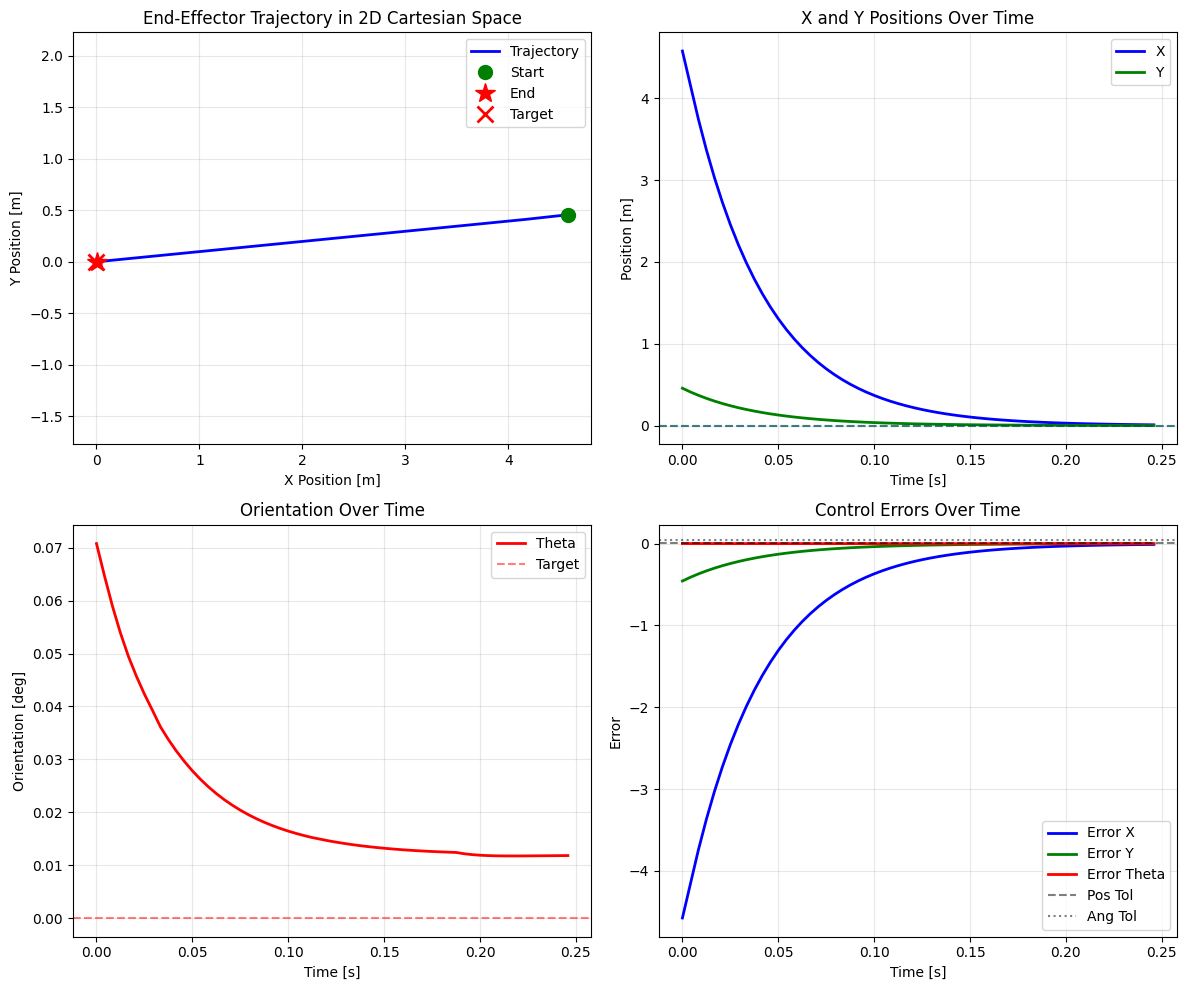


Final State:
  Position: 0.0094, 0.0011 m
  Orientation: 0.01 deg
  Target: 0.0000, 0.0000, 0.00 deg


In [15]:
# Plot trajectory in 2D Cartesian space
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: 2D trajectory
ax = axes[0, 0]
ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Trajectory')
ax.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=10, label='Start')
ax.plot(trajectory[-1, 0], trajectory[-1, 1], 'r*', markersize=15, label='End')
ax.plot(target[0], target[1], 'rx', markersize=12, markeredgewidth=2, label='Target')
ax.set_xlabel('X Position [m]')
ax.set_ylabel('Y Position [m]')
ax.set_title('End-Effector Trajectory in 2D Cartesian Space')
ax.grid(True, alpha=0.3)
ax.legend()
ax.axis('equal')

# Plot 2: X and Y position over time
ax = axes[0, 1]
time = np.arange(len(trajectory)) * control_dt
ax.plot(time, trajectory[:, 0], 'b-', label='X', linewidth=2)
ax.plot(time, trajectory[:, 1], 'g-', label='Y', linewidth=2)
ax.axhline(y=target[0], color='b', linestyle='--', alpha=0.5)
ax.axhline(y=target[1], color='g', linestyle='--', alpha=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Position [m]')
ax.set_title('X and Y Positions Over Time')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Orientation over time
ax = axes[1, 0]
theta_deg = np.degrees(trajectory[:, 2])
target_deg = np.degrees(target[2])
ax.plot(time, theta_deg, 'r-', linewidth=2, label='Theta')
ax.axhline(y=target_deg, color='r', linestyle='--', alpha=0.5, label='Target')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Orientation [deg]')
ax.set_title('Orientation Over Time')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 4: Position error over time
ax = axes[1, 1]
ax.plot(time, errors[:, 0], 'b-', label='Error X', linewidth=2)
ax.plot(time, errors[:, 1], 'g-', label='Error Y', linewidth=2)
ax.plot(time, np.abs(errors[:, 2]), 'r-', label='Error Theta', linewidth=2)
ax.axhline(y=pos_tolerance, color='k', linestyle='--', alpha=0.5, label='Pos Tol')
ax.axhline(y=angle_tolerance, color='k', linestyle=':', alpha=0.5, label='Ang Tol')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Error')
ax.set_title('Control Errors Over Time')
ax.grid(True, alpha=0.3, which='both')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal State:")
print(f"  Position: {trajectory[-1, 0]:.4f}, {trajectory[-1, 1]:.4f} m")
print(f"  Orientation: {np.degrees(trajectory[-1, 2]):.2f} deg")
print(f"  Target: {target[0]:.4f}, {target[1]:.4f}, {np.degrees(target[2]):.2f} deg")

In [ ]:
# Cleanup
# p.disconnect()  # Uncomment to close the simulation
print("Simulation still running. Call p.disconnect() to close when done.")